# **Supervised Learning Classification**

## **Demographic and clinical factors to predict whether a person has heart disease**

*This project uses the UCI Heart Disease dataset to develop and compare classification models for predicting whether a patient has heart disease. The dataset from Kaggle "https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data" includes characteristics such as age, sex, chest pain type, blood pressure, cholesterol, maximum heart rate, and other clinical indicators. The original outcome variable (num) is converted into a binary outcome, where 0 represents no heart disease and 1 represents the presence of heart disease. The project includes data preprocessing, exploratory data analysis, model training, and evaluation using metrics such as accuracy, precision, recall, F1-score, and ROC-AUC.*

### **Import Libraries and Load the dataset**

In [2]:
# Import data manipulation libraries
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Model evaluation
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

In [3]:
# Load the dataset
 
heart_data = pd.read_csv("heart_disease_uci.csv")

**Inspect to understanf the dataset**

In [4]:
# Display first 5 rows
heart_data.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [5]:
# Check data types and missing values
heart_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB


In [ ]:
# Summary statistics

heart_data.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [7]:
# Check missing values
heart_data.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [ ]:
# Check duplicates

heart_data.duplicated().sum()

np.int64(0)

In [9]:
# Examine the outcome variable

heart_data['num'].value_counts().sort_index()

num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

In [19]:
heart_data['dataset'].value_counts()

dataset
Cleveland        304
Hungary          293
VA Long Beach    200
Switzerland      123
Name: count, dtype: int64

### **1. Data Preporcessing**

In [10]:
# Check and handle missing values

heart_data.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

### **Handle numerical and categorical missing values**

In [12]:
# Separate numerical values from categorical values

# Numerical columns

numeric_cols = [
    'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']

# Categorical columns

categorical_cols = [
    'fbs', 'restecg', 'exang', 'slope', 'thal']

In [13]:
# Fill numerical missing values with the median

for col in numeric_cols:
    heart_data[col] = heart_data[col].fillna(
        heart_data[col].median())

In [14]:
# Fill categorical missing values with the mode

for col in categorical_cols:
    heart_data[col] = heart_data[col].fillna(heart_data[col].mode()[0])

In [16]:
# Verify after filling in
 
heart_data.isnull().sum()

id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

In [ ]:
# Handle duplicates

heart_data.duplicated().sum()

np.int64(0)

### **Create a binary outcome**

In [20]:
# Create the binary outcome variable

heart_data['HeartDisease'] = (heart_data['num'] > 0).astype(int)

In [24]:
# Remove columns that will not be used in our model

heart_data.drop(
    columns=['id', 'dataset', 'num'],
    inplace=True)

### **Encode categorical variables**

In [26]:
# Identify categorical variables 

heart_data.select_dtypes(include=['object', 'str']).columns

Index(['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal'], dtype='str')

In [27]:
# Encode the categorical variables

heart_data = pd.get_dummies(
    heart_data,
    drop_first=True,
    dtype=int)

In [28]:
heart_data.head()

,age,trestbps,chol,thalch,oldpeak,ca,HeartDisease,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,fbs_True,restecg_normal,restecg_st-t abnormality,exang_True,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63,145.0,233.0,150.0,2.3,0.0,0,1,0,0,1,1,0,0,0,0,0,0,0
1,67,160.0,286.0,108.0,1.5,3.0,1,1,0,0,0,0,0,0,1,1,0,1,0
2,67,120.0,229.0,129.0,2.6,2.0,1,1,0,0,0,0,0,0,1,1,0,0,1
3,37,130.0,250.0,187.0,3.5,0.0,0,1,0,1,0,0,1,0,0,0,0,1,0
4,41,130.0,204.0,172.0,1.4,0.0,0,0,1,0,0,0,0,0,0,0,1,1,0


### **Split the dataset into training and testing sets**

In [31]:
# Define predictors and outcome

x = heart_data.drop('HeartDisease', axis=1)

y = heart_data['HeartDisease']

In [33]:
# Split into training and testing sets

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.20,random_state=42,stratify=y)

## **2. Exploratory Data Analysis (EDA)**

### **Distribution of classes**

In [37]:
# Check the number of patients in each outcome class:

heart_data['HeartDisease'].value_counts()

HeartDisease
1    509
0    411
Name: count, dtype: int64

In [36]:
# Present in percentage

heart_data['HeartDisease'].value_counts(normalize=True).round(3) * 100

HeartDisease
1    55.3
0    44.7
Name: proportion, dtype: float64

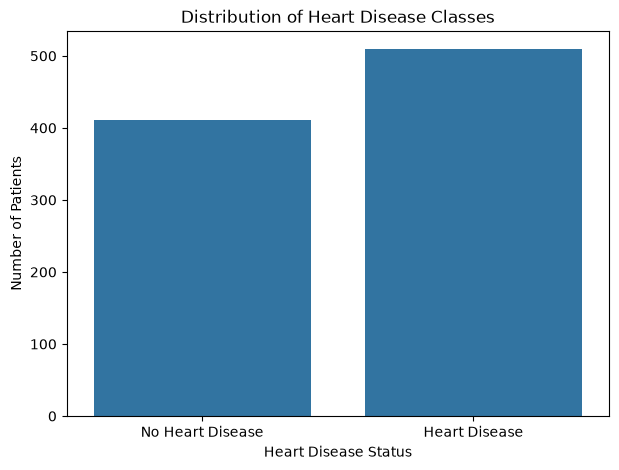

In [ ]:
# Visualize the distribution of outcome classes

plt.figure(figsize=(7, 5))

sns.countplot(data=heart_data, x='HeartDisease')

plt.title('Distribution of Heart Disease Classes')
plt.xlabel('Heart Disease Status')
plt.ylabel('Number of Patients')
plt.xticks([0, 1], ['No Heart Disease', 'Heart Disease'])

plt.show()

### **Correlation between features**

In [ ]:
# calculate correlations

correlation_matrix = heart_data.corr()

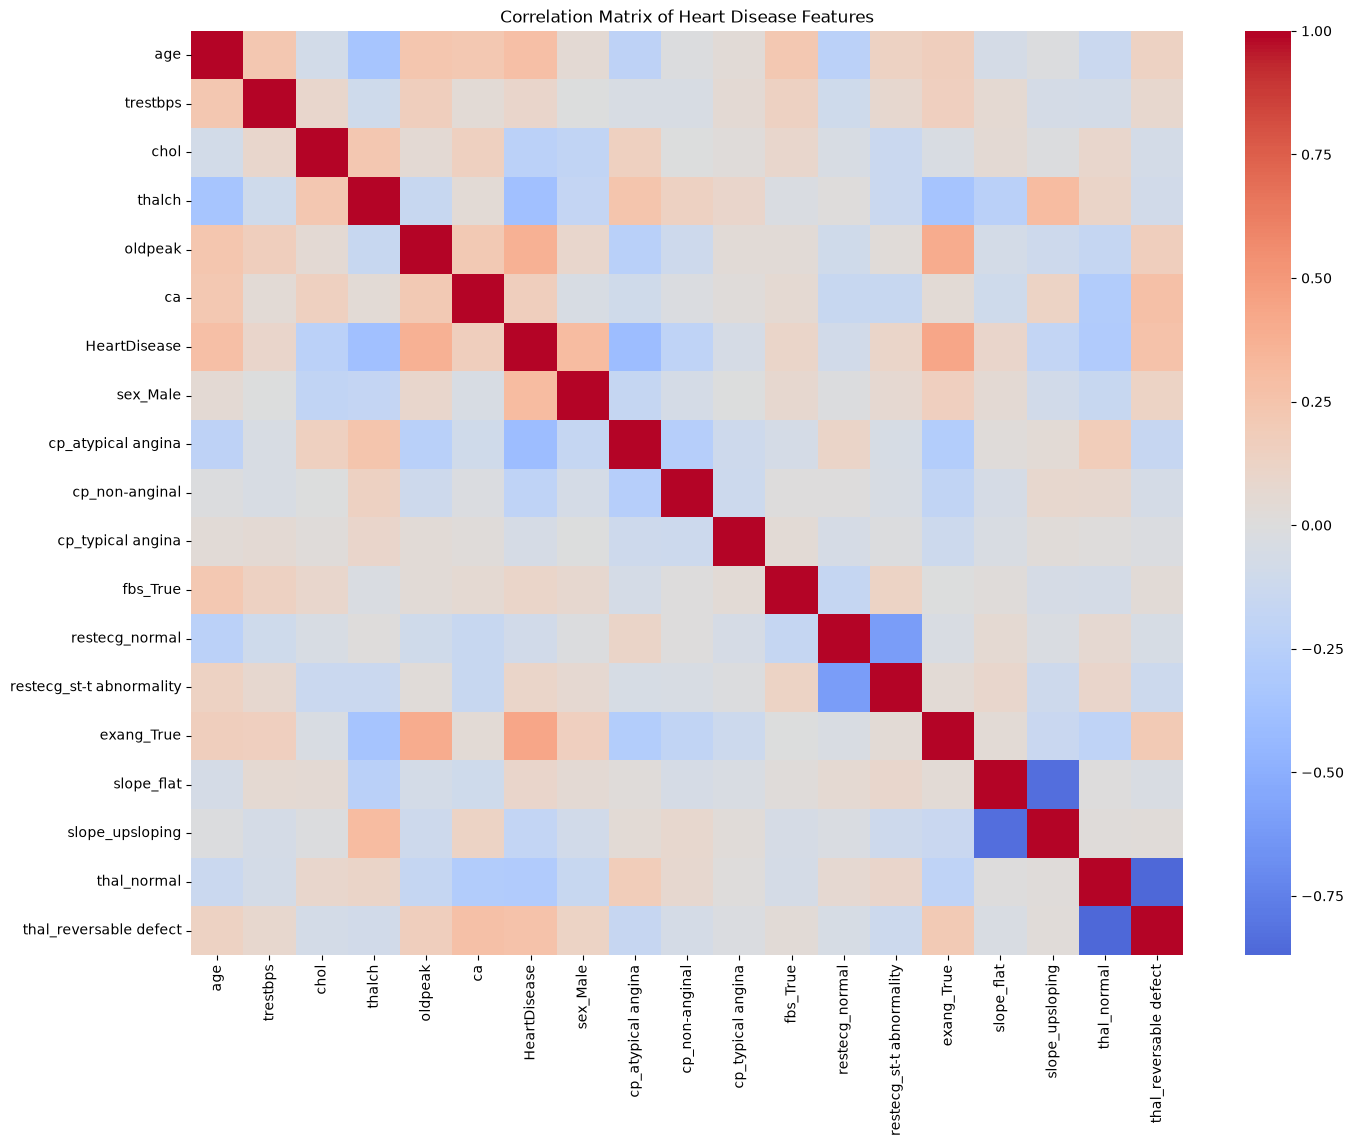

In [43]:
# create a heatmap

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    cmap='coolwarm',
    center=0)

plt.title('Correlation Matrix of Heart Disease Features')

plt.show()

#### **Insights**: TThe EDA indicates a moderate class imbalance and mostly weak-to-moderate relationships between individual predictors and heart disease. This suggests that classification will likely depend on combining several patient characteristics. Logistic Regression provides an interpretable baseline for linear relationships, while Random Forest can capture more complex interactions and nonlinear relationships. Because the classes are not perfectly balanced, accuracy will be evaluated together with precision, recall, F1-score, and ROC-AUC to obtain a more reliable assessment of model performance.

## **3. Model Implementation and Evaluation**

In [45]:
# Standardize the predictors

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

#### **Logisic Regression model**

In [46]:
# Create Logistic Regression model

log_model = LogisticRegression(
    max_iter=1000,
    random_state=42)

# Train model
log_model.fit(x_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [47]:
# Predict classes

y_pred_log = log_model.predict(x_test_scaled)

# Predict probabilities for ROC-AUC
y_prob_log = log_model.predict_proba(x_test_scaled)[:, 1]

In [ ]:
# Evaluate and Display the classification report

print(classification_report(
    y_test,
    y_pred_log,
    target_names=['No Heart Disease', 'Heart Disease']))

                  precision    recall  f1-score   support

No Heart Disease       0.84      0.79      0.82        82
   Heart Disease       0.84      0.88      0.86       102

        accuracy                           0.84       184
       macro avg       0.84      0.84      0.84       184
    weighted avg       0.84      0.84      0.84       184

